# 実行準備

## ライブラリのインストール

In [1]:
import sys
print(sys.executable)

c:\学習\repo_del\cleanrepo\selfstudy_assistance_agent\.venv\Scripts\python.exe


In [3]:
!{sys.executable} -m pip install matplotlib

  Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl (73 kB)
Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl (7.1 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsing]
   -


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!{sys.executable} -m pip show matplotlib

Name: matplotlib
Version: 3.10.9
Summary: Python plotting package
Home-page: https://matplotlib.org
Author: John D. Hunter, Michael Droettboom
Author-email: Unknown <matplotlib-users@python.org>
License: License agreement for matplotlib versions 1.3.0 and later

 1. This LICENSE AGREEMENT is between the Matplotlib Development Team
 ("MDT"), and the Individual or Organization ("Licensee") accessing and
 otherwise using matplotlib software in source or binary form and its
 associated documentation.

 2. Subject to the terms and conditions of this License Agreement, MDT
 hereby grants Licensee a nonexclusive, royalty-free, world-wide license
 to reproduce, analyze, test, perform and/or display publicly, prepare
 derivative works, distribute, and otherwise use matplotlib
 alone or in any derivative version, provided, however, that MDT's
 License Agreement and MDT's notice of copyright, i.e., "Copyright (c)
 2012- Matplotlib Development Team; All Rights Reserved" are retained in
 matplotlib

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import json
from pathlib import Path
import os

In [11]:
file_num = len(os.listdir('./output/radar/'))-1
file_num

0

In [ ]:
json_str = { 
"base": [
    {"skill": "8-8", "level": 1}
],
"value": [],
"DS": [
    {"skill": "337-14", "level": 3},
    {"skill": "26-16", "level": 2},
    {"skill": "124-3", "level": 3},
    {"skill": "189-32", "level": 1},
    {"skill": "57-47", "level": 1}
],
"DE": [
    {"skill": "166-8", "level": 2},
    {"skill": "158-20", "level": 2},
    {"skill": "54-19", "level": 3},
    {"skill": "170-12", "level": 2},
    {"skill": "145-7", "level": 2}
],
"fusion": [
    {"skill": "44-18", "level": 3},
    {"skill": "117-10", "level": 3},
    {"skill": "30-4", "level": 3},
    {"skill": "103-12", "level": 3},
    {"skill": "90-14", "level": 3}
]
}

# ⑧ レーダーチャート用の集計
radar = {}
for category, items in json_str.items():
    total = 0
    for item in items:
        level = item.get("level", 0)
        total += int(level)
    radar[category] = total


In [8]:
radar

{'base': 1, 'value': 0, 'DS': 10, 'DE': 11, 'fusion': 15}

In [9]:
# カテゴリ
categories = ["base", "value", "DS", "DE", "fusion"]

# 合計値
values = []
for cat in categories: 
    # total = sum(item["level"] for item in radar.get(cat, []))
    values.append(radar[cat])

# レーダーチャートは最初の値を最後に追加して閉じる
values += values[:1]

# 角度を計算
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]


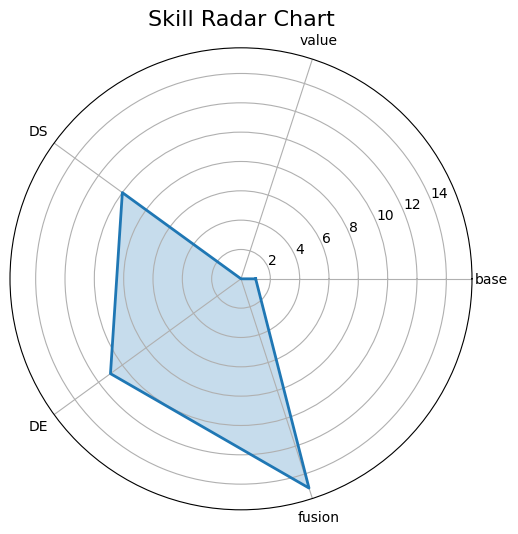

In [12]:
# 描画
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

ax.plot(angles, values, linewidth=2)
ax.fill(angles, values, alpha=0.25)

# 軸ラベル
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

# タイトル
ax.set_title("Skill Radar Chart", fontsize=16)

# ファイル出力
plt.savefig(f"./output/radarchart/radarchart_{file_num}.png")
plt.show()


In [9]:
# データの読み込み
file_num = len(os.listdir('../output/radar/'))-1
radar_path = f"../output/radar/radar_{file_num}.json"
radar_path = Path(radar_path)
with open(radar_path, "r", encoding="utf-8-sig") as f:
    skill_json = json.load(f)


In [10]:
skill_json

{'base': 0, 'value': 0, 'DS': 0, 'DE': 0, 'fusion': 0}

In [7]:
# カテゴリ
categories = ["base", "value", "DS", "DE", "fusion"]

# 合計値
values = []
for cat in categories: 
    total = sum(item["level"] for item in skill_json.get(cat, []))
    values.append(total)

# レーダーチャートは最初の値を最後に追加して閉じる
values += values[:1]

# 角度を計算
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]


NameError: name 'skill_json' is not defined

In [ ]:
# 描画
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

ax.plot(angles, values, linewidth=2)
ax.fill(angles, values, alpha=0.25)

# 軸ラベル
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

# タイトル
ax.set_title("Skill Radar Chart", fontsize=16)

# ファイル出力
plt.savefig(f"./output/radarchart/radarchart_{file_num}.png")
plt.show()
